In [1]:
"""
Neural Bites — Complete ML Pipeline (v2.0)
==========================================
Mobile-deployment-ready pipeline for fruit quality detection
and formalin contamination identification.

Pipeline:
  YOLO (fine-tuned) → MobileNetV2 (multi-head) → OOD Detection

Output files for Android APK:
  1. yolo_fruits.tflite        — fruit detection
  2. fruit_classifier.tflite   — condition classification + attention
  3. ood_config.json           — non-target fruit rejection

Author: Mohammod Hamed Hasan
"""

'\nNeural Bites — Complete ML Pipeline (v2.0)\n==========================================\nMobile-deployment-ready pipeline for fruit quality detection\nand formalin contamination identification.\n\nPipeline:\n  YOLO (fine-tuned) → MobileNetV2 (multi-head) → OOD Detection\n\nOutput files for Android APK:\n  1. yolo_fruits.tflite        — fruit detection\n  2. fruit_classifier.tflite   — condition classification + attention\n  3. ood_config.json           — non-target fruit rejection\n\nAuthor: Mohammod Hamed Hasan\n'

In [2]:
import os
print(os.path.exists("/kaggle/working/yolo_runs/fruit_detect/weights/last.pt"))

True


# Section 0 — Setup & Configuration
Global paths, seeds, constants, and checkpoint directory.

In [3]:
# Must run BEFORE any torch/ultralytics imports — RESTART KERNEL after this completes
!pip uninstall -y torch torchvision torchaudio -q
!pip install torch==2.4.1 torchvision==0.19.1 --index-url https://download.pytorch.org/whl/cu121 -q
!pip install "ultralytics==8.3.40" -q

# Re-pin torch+torchvision AFTER ultralytics, in case its dependency resolver upgraded torchvision
!pip install torch==2.4.1 torchvision==0.19.1 --index-url https://download.pytorch.org/whl/cu121 -q --force-reinstall --no-deps

print("✓ Torch downgrade complete — RESTART THE KERNEL NOW, then run cells from the top.")

✓ Torch downgrade complete — RESTART THE KERNEL NOW, then run cells from the top.


In [4]:
import os, sys, glob, copy, time, random, json, shutil, warnings
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from collections import Counter, OrderedDict
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torchvision import models, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore", category=UserWarning)

# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Paths ────────────────────────────────────────────────────────────
import kagglehub
dataset_path   = kagglehub.dataset_download("ahmadfauzi89/fruitvision-mendeley")
DATA_DIR       = os.path.join(dataset_path, "Fruits Original")

WORK_DIR       = "/kaggle/working"
CHECKPOINT_DIR = os.path.join(WORK_DIR, "checkpoints")
EXPORT_DIR     = os.path.join(WORK_DIR, "mobile_deploy")
YOLO_DIR       = os.path.join(WORK_DIR, "yolo_dataset")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR,     exist_ok=True)
os.makedirs(YOLO_DIR,       exist_ok=True)

# ── Device setup with GPU sanity check ───────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if DEVICE.type == "cpu":
    warnings.warn("⚠️ CUDA not available — training will run on CPU and will be very slow.")
else:
    try:
        _ = (torch.randn(10, 10).to(DEVICE) @ torch.randn(10, 10).to(DEVICE))
        print(f"✓ GPU kernel check passed: {torch.cuda.get_device_name(0)} "
              f"(compute capability {torch.cuda.get_device_capability(0)})")
    except RuntimeError as e:
        raise RuntimeError(
            f"CUDA device found but kernel execution failed: {e}\n"
            f"torch={torch.__version__}, cuda={torch.version.cuda}, "
            f"arch_list={torch.cuda.get_arch_list()}"
        ) from e

IMG_SIZE = 384   # Higher res preserves formalin's color-loss signature

# ── Fruit & condition mappings ───────────────────────────────────────
FRUIT_NAMES     = ["Apple", "Banana", "Grape", "Mango", "Orange"]
CONDITION_NAMES = ["Formalin-mixed", "Fresh", "Rotten"]
NUM_FRUITS      = len(FRUIT_NAMES)
NUM_CONDITIONS  = len(CONDITION_NAMES)

FRUIT_TO_ID     = {f: i for i, f in enumerate(FRUIT_NAMES)}
CONDITION_TO_ID = {c: i for i, c in enumerate(CONDITION_NAMES)}

print(f"Device: {DEVICE}")
print(f"Dataset: {DATA_DIR}")
print(f"Working: {WORK_DIR}")

✓ GPU kernel check passed: Tesla P100-PCIE-16GB (compute capability (6, 0))
Device: cuda
Dataset: /kaggle/input/datasets/ahmadfauzi89/fruitvision-mendeley/Fruits Original
Working: /kaggle/working


# Section 1 — Dataset Class
Two-level walk: Fruit → Condition → images. Each image gets **three labels**: combined class (15-way), fruit index (5-way), and condition index (3-way).

In [5]:
class FruitConditionDataset(Dataset):
    """
    Dataset with triple labeling: combined class, fruit, and condition.

    Directory: root / FruitName / Condition / image.jpg
    Combined label: "FruitName-Condition" (15 classes)
    """
    VALID_EXT = {'.jpg', '.jpeg', '.png'}

    def __init__(self, root_dir, transform=None):
        self.root_dir  = root_dir
        self.transform = transform
        all_entries    = []
        class_names    = set()

        for fruit in sorted(os.listdir(root_dir)):
            fp = os.path.join(root_dir, fruit)
            if not os.path.isdir(fp):
                continue
            for cond in sorted(os.listdir(fp)):
                cp = os.path.join(fp, cond)
                if not os.path.isdir(cp):
                    continue
                label = f"{fruit}-{cond}"
                class_names.add(label)
                for fn in os.listdir(cp):
                    if os.path.splitext(fn)[1].lower() in self.VALID_EXT:
                        all_entries.append((os.path.join(cp, fn), label, fruit, cond))

        self.classes      = sorted(class_names)
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples      = [(p, self.class_to_idx[lbl], FRUIT_TO_ID[fr], CONDITION_TO_ID[co])
                             for p, lbl, fr, co in all_entries]
        self.targets       = [s[1] for s in self.samples]   # combined 15-class
        self.fruit_targets = [s[2] for s in self.samples]   # 5-class
        self.cond_targets  = [s[3] for s in self.samples]   # 3-class

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, combo_lbl, fruit_lbl, cond_lbl = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, combo_lbl, fruit_lbl, cond_lbl


full_dataset = FruitConditionDataset(DATA_DIR)
print(f"Total images: {len(full_dataset)}")
print(f"Combined classes ({len(full_dataset.classes)}):")
dist = Counter(full_dataset.targets)
for cls in full_dataset.classes:
    idx = full_dataset.class_to_idx[cls]
    print(f"  {cls}: {dist[idx]}")

Total images: 10154
Combined classes (15):
  Apple-Formalin-mixed: 643
  Apple-Fresh: 765
  Apple-Rotten: 630
  Banana-Formalin-mixed: 660
  Banana-Fresh: 749
  Banana-Rotten: 632
  Grape-Formalin-mixed: 610
  Grape-Fresh: 770
  Grape-Rotten: 630
  Mango-Formalin-mixed: 616
  Mango-Fresh: 763
  Mango-Rotten: 630
  Orange-Formalin-mixed: 647
  Orange-Fresh: 753
  Orange-Rotten: 656


# Section 2 — Visualize Samples
One sample per class to verify dataset loading.

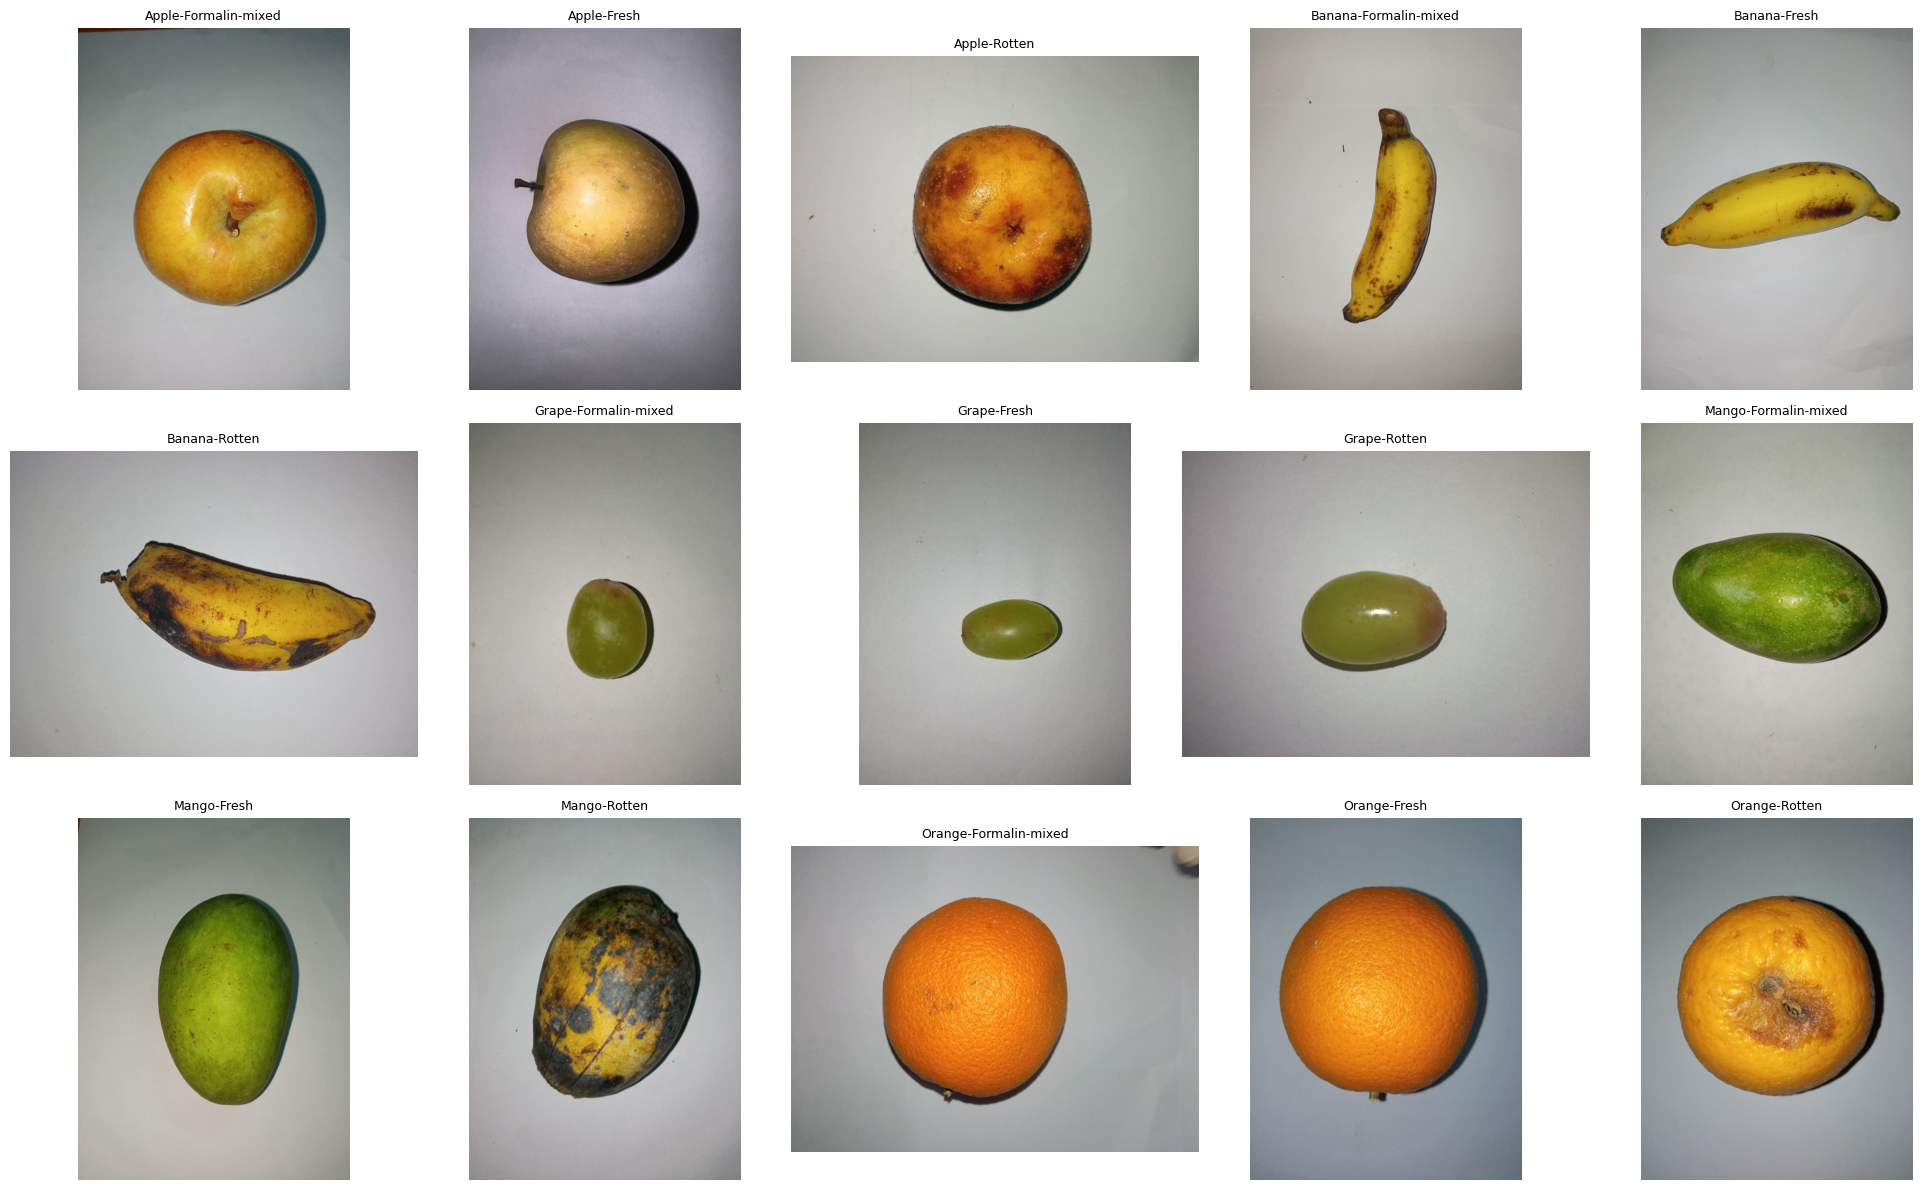

In [6]:
n_cls = len(full_dataset.classes)
cols  = min(5, n_cls)
rows  = (n_cls + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = np.array(axes).flatten()

shown = set()
for path, combo, fr, co in full_dataset.samples:
    if combo not in shown:
        ax = axes[combo]
        ax.imshow(Image.open(path))
        ax.set_title(full_dataset.classes[combo], fontsize=9)
        ax.axis('off')
        shown.add(combo)
    if len(shown) == n_cls:
        break
for i in range(n_cls, len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Section 3 — Auto-Generate YOLO Bounding Box Annotations
Detect each fruit's region using HSV color segmentation, then write YOLO-format `.txt` files.  
Fallback to full-image bbox when color detection fails.  
YOLO class labels are **fruit type only** (5 classes), not condition.

In [7]:
# HSV colour ranges per fruit (tuned for typical dataset lighting)
# Each fruit may have multiple hue ranges (e.g., Apple: red wraps 0-10 and 160-180)
HSV_RANGES = {
    'Apple':  [
        {'lower': np.array([0,   40, 40]), 'upper': np.array([15,  255, 255])},
        {'lower': np.array([160, 40, 40]), 'upper': np.array([180, 255, 255])},
    ],
    'Banana': [
        {'lower': np.array([18, 60, 80]),  'upper': np.array([35, 255, 255])},
    ],
    'Grape':  [
        {'lower': np.array([125, 30, 30]), 'upper': np.array([160, 255, 255])},
        {'lower': np.array([0,   30, 30]), 'upper': np.array([10,  200, 120])},  # dark reds
    ],
    'Mango':  [
        {'lower': np.array([12, 80, 80]),  'upper': np.array([38, 255, 255])},
    ],
    'Orange': [
        {'lower': np.array([8, 100, 80]),  'upper': np.array([22, 255, 255])},
    ],
}


def auto_bbox(image_path, fruit_type, pad_frac=0.10):
    """
    Detect fruit region via HSV masking → contour → padded bbox.
    Returns normalised YOLO coords: (cx, cy, w, h) all in [0,1].
    Falls back to (0.5, 0.5, 1.0, 1.0) on failure.
    """
    FALLBACK = (0.5, 0.5, 1.0, 1.0)
    img = cv2.imread(str(image_path))
    if img is None:
        return FALLBACK, True

    h_img, w_img = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Union of all HSV ranges for this fruit
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for rng in HSV_RANGES.get(fruit_type, []):
        mask |= cv2.inRange(hsv, rng['lower'], rng['upper'])

    # Morphological cleanup
    kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kern, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kern, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return FALLBACK, True

    # Largest contour = fruit
    biggest = max(contours, key=cv2.contourArea)
    # Reject if area too small (< 5 % of image) — likely noise
    if cv2.contourArea(biggest) < 0.05 * h_img * w_img:
        return FALLBACK, True

    x, y, w, h = cv2.boundingRect(biggest)

    # Add padding
    px, py = int(w * pad_frac), int(h * pad_frac)
    x1 = max(0, x - px)
    y1 = max(0, y - py)
    x2 = min(w_img, x + w + px)
    y2 = min(h_img, y + h + py)

    cx = (x1 + x2) / 2.0 / w_img
    cy = (y1 + y2) / 2.0 / h_img
    bw = (x2 - x1) / w_img
    bh = (y2 - y1) / h_img
    return (cx, cy, bw, bh), False


# ── Generate annotations for ALL images ──────────────────────────────
# We also do stratified split into train/val/test here for YOLO

from sklearn.model_selection import StratifiedShuffleSplit as SSS

all_yolo_entries = []   # (image_path, fruit_type, fruit_id)

for fruit in sorted(os.listdir(DATA_DIR)):
    fp = os.path.join(DATA_DIR, fruit)
    if not os.path.isdir(fp) or fruit not in FRUIT_TO_ID:
        continue
    for cond in sorted(os.listdir(fp)):
        cp = os.path.join(fp, cond)
        if not os.path.isdir(cp):
            continue
        for fn in os.listdir(cp):
            ext = os.path.splitext(fn)[1].lower()
            if ext in {'.jpg', '.jpeg', '.png'}:
                all_yolo_entries.append((os.path.join(cp, fn), fruit, FRUIT_TO_ID[fruit]))

print(f"Total images for YOLO: {len(all_yolo_entries)}")

# Stratified split by fruit type (80/10/10)
yolo_labels = np.array([e[2] for e in all_yolo_entries])
sss1 = SSS(n_splits=1, test_size=0.20, random_state=SEED)
train_rel, temp_rel = next(sss1.split(np.zeros(len(yolo_labels)), yolo_labels))

temp_labels = yolo_labels[temp_rel]
sss2 = SSS(n_splits=1, test_size=0.50, random_state=SEED)
val_rel, test_rel = next(sss2.split(np.zeros(len(temp_labels)), temp_labels))
val_abs  = temp_rel[val_rel]
test_abs = temp_rel[test_rel]

split_map = {}
for i in train_rel: split_map[i] = 'train'
for i in val_abs:   split_map[i] = 'val'
for i in test_abs:  split_map[i] = 'test'

# Create directory tree
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(YOLO_DIR, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DIR, 'labels', split), exist_ok=True)

# Process each image
stats = {'total': 0, 'detected': 0, 'fallback': 0}

for idx, (img_path, fruit, fid) in enumerate(tqdm(all_yolo_entries, desc="Generating BBoxes")):
    split = split_map[idx]
    bbox, is_fallback = auto_bbox(img_path, fruit)

    stats['total'] += 1
    if is_fallback:
        stats['fallback'] += 1
    else:
        stats['detected'] += 1

    # Copy image to YOLO directory
    ext   = os.path.splitext(img_path)[1]
    fname = f"{fruit}_{idx:05d}{ext}"
    dst_img = os.path.join(YOLO_DIR, 'images', split, fname)
    shutil.copy2(img_path, dst_img)

    # Write label file
    dst_lbl = os.path.join(YOLO_DIR, 'labels', split, fname.replace(ext, '.txt'))
    cx, cy, w, h = bbox
    with open(dst_lbl, 'w') as f:
        f.write(f"{fid} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

print(f"\n✓ BBox generation complete")
print(f"  Detected: {stats['detected']}  |  Fallback: {stats['fallback']}")
for split in ['train', 'val', 'test']:
    n = len(os.listdir(os.path.join(YOLO_DIR, 'images', split)))
    print(f"  {split}: {n} images")

Total images for YOLO: 10154


Generating BBoxes:   0%|          | 0/10154 [00:00<?, ?it/s]


✓ BBox generation complete
  Detected: 6790  |  Fallback: 3364
  train: 8123 images
  val: 1015 images
  test: 1016 images


# Section 4 — Validate YOLO Annotations
Verify format and visualise a few samples to QA the bounding boxes.

  train: ✓ OK
  val: ✓ OK
  test: ✓ OK
Total issues: 0


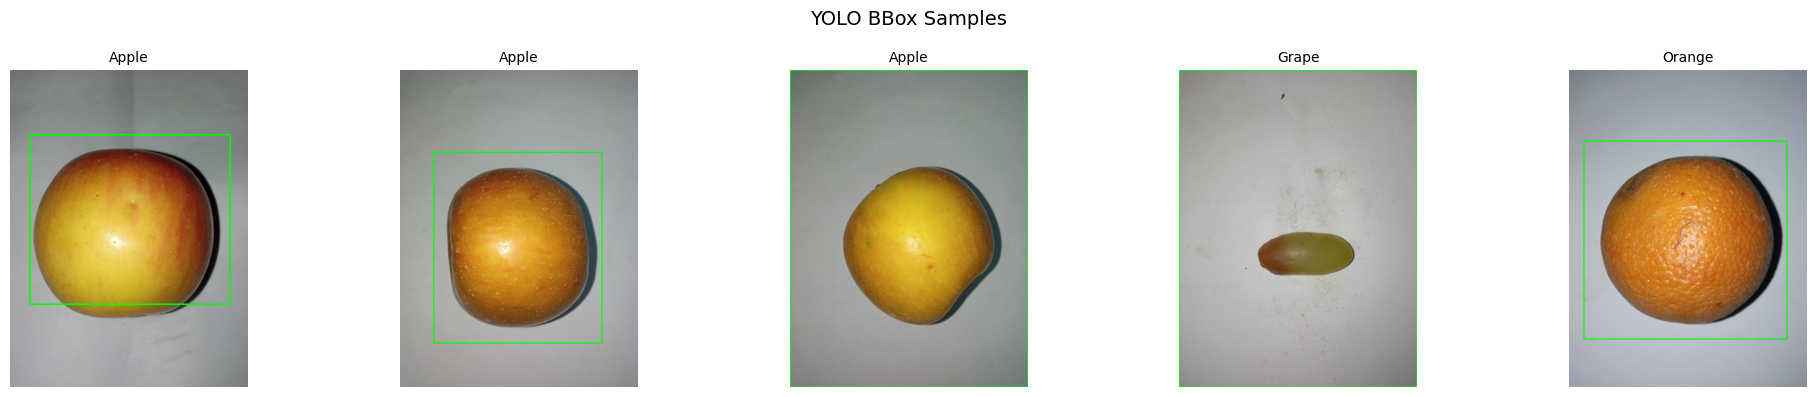

In [8]:
def validate_yolo(labels_dir):
    issues = 0
    for txt in Path(labels_dir).rglob("*.txt"):
        with open(txt) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    issues += 1; continue
                cid, cx, cy, w, h = map(float, parts)
                if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 < w <= 1 and 0 < h <= 1):
                    issues += 1
                if int(cid) not in range(NUM_FRUITS):
                    issues += 1
    return issues

issues = 0
for split in ['train', 'val', 'test']:
    n = validate_yolo(os.path.join(YOLO_DIR, 'labels', split))
    issues += n
    print(f"  {split}: {'✓ OK' if n == 0 else f'{n} issues'}")
print(f"Total issues: {issues}")

# Visualise 5 random samples
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
img_files = list(Path(YOLO_DIR, 'images', 'train').glob('*.*'))
samples   = random.sample(img_files, min(5, len(img_files)))

for ax, img_path in zip(axes, samples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ih, iw = img.shape[:2]
    txt_path = str(img_path).replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    if os.path.exists(txt_path):
        with open(txt_path) as f:
            cid, cx, cy, bw, bh = map(float, f.read().strip().split())
        x1 = int((cx - bw/2)*iw); y1 = int((cy - bh/2)*ih)
        x2 = int((cx + bw/2)*iw); y2 = int((cy + bh/2)*ih)
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 3)
        ax.set_title(f"{FRUIT_NAMES[int(cid)]}", fontsize=10)
    ax.imshow(img); ax.axis('off')
plt.suptitle("YOLO BBox Samples", fontsize=14)
plt.tight_layout(); plt.show()

# Section 5 — Create YOLO `data.yaml`

In [9]:
import yaml

data_yaml = {
    'path': YOLO_DIR,
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc':    NUM_FRUITS,
    'names': FRUIT_NAMES,
}

yaml_path = os.path.join(YOLO_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"✓ data.yaml saved to {yaml_path}")
print(open(yaml_path).read())

✓ data.yaml saved to /kaggle/working/yolo_dataset/data.yaml
names:
- Apple
- Banana
- Grape
- Mango
- Orange
nc: 5
path: /kaggle/working/yolo_dataset
test: images/test
train: images/train
val: images/val



# Section 6 — Fine-Tune YOLOv8-nano on Fruit Dataset
Start from COCO pretrained weights and fine-tune for 50 epochs.  
**Checkpoint support:** YOLO auto-saves `last.pt`; on session restart the `resume=True` flag loads it and continues from the last completed epoch.

In [10]:
import subprocess, importlib
if importlib.util.find_spec("ultralytics") is None:
    subprocess.check_call(["pip", "install", "ultralytics", "-q"])

from ultralytics import YOLO as UltralyticsYOLO

YOLO_EPOCHS   = 50
YOLO_BATCH    = 32
YOLO_IMGSZ    = 640
YOLO_PATIENCE = 20
YOLO_PROJECT  = os.path.join(WORK_DIR, "yolo_runs")
YOLO_RUN_NAME = "fruit_detect"

last_pt = os.path.join(YOLO_PROJECT, YOLO_RUN_NAME, "weights", "last.pt")
best_pt_check = os.path.join(YOLO_PROJECT, YOLO_RUN_NAME, "weights", "best.pt")
resume_training = os.path.exists(last_pt)

if resume_training:
    try:
        print(f"♻️  Attempting to resume YOLO training from {last_pt}")
        yolo_model = UltralyticsYOLO(last_pt)
        results = yolo_model.train(resume=True)
    except AssertionError as e:
        if "nothing to resume" in str(e):
            print("✓ YOLO training was already complete. Loading final weights instead.")
            yolo_model = UltralyticsYOLO(best_pt_check if os.path.exists(best_pt_check) else last_pt)
        else:
            raise
else:
    print("🚀 Starting YOLO training from COCO pretrained weights")
    yolo_model = UltralyticsYOLO("yolov8n.pt")
    results = yolo_model.train(
        data      = yaml_path,
        epochs    = YOLO_EPOCHS,
        batch     = YOLO_BATCH,
        imgsz     = YOLO_IMGSZ,
        patience  = YOLO_PATIENCE,
        project   = YOLO_PROJECT,
        name      = YOLO_RUN_NAME,
        exist_ok  = True,
        seed      = SEED,
        verbose   = True,
    )

print("\n✓ YOLO training step done.")

♻️  Attempting to resume YOLO training from /kaggle/working/yolo_runs/fruit_detect/weights/last.pt
New https://pypi.org/project/ultralytics/8.4.93 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.4.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=/kaggle/working/yolo_runs/fruit_detect/weights/last.pt, data=/kaggle/working/yolo_dataset/data.yaml, epochs=50, time=None, patience=20, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=/kaggle/working/yolo_runs, name=fruit_detect, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=/kaggle/working/yolo_runs/fruit_detect/weights/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=Fa

train: Scanning /kaggle/working/yolo_dataset/labels/train.cache... 8123 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8123/8123 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 1015 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1015/1015 [00:00<?, ?it/s]


Plotting labels to /kaggle/working/yolo_runs/fruit_detect/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
✓ YOLO training was already complete. Loading final weights instead.

✓ YOLO training step done.


In [11]:
import torch, torchvision
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
import torchvision.models
print("✓ torchvision import successful")

torch: 2.4.1+cu121
torchvision: 0.19.1+cu121
✓ torchvision import successful


# Section 7 — Evaluate YOLO on Test Set

In [12]:
# Load best model
best_pt = os.path.join(YOLO_PROJECT, YOLO_RUN_NAME, "weights", "best.pt")
yolo_best = UltralyticsYOLO(best_pt)

# Validate on test split
metrics = yolo_best.val(data=yaml_path, split="test")

print(f"\n{'='*50}")
print(f"YOLO Test Results")
print(f"{'='*50}")
print(f"  mAP50:    {metrics.box.map50:.4f}")
print(f"  mAP50-95: {metrics.box.map:.4f}")
print(f"  Precision: {metrics.box.mp:.4f}")
print(f"  Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.4.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 168 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /kaggle/working/yolo_dataset/labels/test.cache... 1016 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1016/1016 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 64/64 [00:09<00:00,  6.95it/s]


                   all       1016       1016      0.989      0.988      0.994      0.981
                 Apple        204        204      0.968      0.966       0.99      0.968
                Banana        204        204      0.995      0.995      0.995      0.985
                 Grape        201        201      0.998          1      0.995      0.995
                 Mango        201        201      0.985      0.979      0.994      0.965
                Orange        206        206      0.998          1      0.995      0.994
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/val5

YOLO Test Results
  mAP50:    0.9938
  mAP50-95: 0.9814
  Precision: 0.9888
  Recall:    0.9880


# Section 8 — Export YOLO to TFLite

In [13]:
import sys, types, importlib.util

if 'imp' not in sys.modules:
    imp_shim = types.ModuleType('imp')
    imp_shim.reload = importlib.reload

    def _find_module(name, path=None):
        spec = importlib.util.find_spec(name)
        if spec is None:
            raise ImportError(f"No module named {name!r}")
        return spec

    imp_shim.find_module = _find_module
    sys.modules['imp'] = imp_shim

print("✓ 'imp' shim installed for Python 3.12 compatibility")

✓ 'imp' shim installed for Python 3.12 compatibility


In [14]:
yolo_export_path = yolo_best.export(format="tflite", imgsz=YOLO_IMGSZ)

# Copy to export directory
yolo_tflite_src  = str(yolo_export_path)
yolo_tflite_dst  = os.path.join(EXPORT_DIR, "yolo_fruits.tflite")
shutil.copy2(yolo_tflite_src, yolo_tflite_dst)

size_mb = os.path.getsize(yolo_tflite_dst) / 1024 / 1024
print(f"✓ YOLO TFLite exported: {yolo_tflite_dst} ({size_mb:.1f} MB)")

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.4.1+cu121 CPU (Intel Xeon 2.00GHz)

PyTorch: starting from '/kaggle/working/yolo_runs/fruit_detect/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (5.9 MB)

TensorFlow SavedModel: starting export with tensorflow 2.20.0...

ONNX: starting export with onnx 1.22.0 opset 19...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.3s, saved as '/kaggle/working/yolo_runs/fruit_detect/weights/best.onnx' (11.8 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.22.3...


I0000 00:00:1783940636.231515    4511 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14731 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1783940682.071283    4511 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1783940682.071492    4511 single_machine.cc:376] Starting new session
I0000 00:00:1783940682.072655    4511 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14731 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
W0000 00:00:1783940682.813926    4511 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783940682.813966    4511 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1783940683.516871    4511 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0

TensorFlow SavedModel: export success ✅ 50.8s, saved as '/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model' (29.5 MB)

TensorFlow Lite: starting export with tensorflow 2.20.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float32.tflite' (11.7 MB)

Export complete (51.1s)
Results saved to /kaggle/working/yolo_runs/fruit_detect/weights
Predict:         yolo predict task=detect model=/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float32.tflite imgsz=640  
Validate:        yolo val task=detect model=/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float32.tflite imgsz=640 data=/kaggle/working/yolo_dataset/data.yaml  
Visualize:       https://netron.app
✓ YOLO TFLite exported: /kaggle/working/mobile_deploy/yolo_fruits.tflite (11.7 MB)


In [15]:
import os
tflite_path = "/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model"
for root, dirs, files in os.walk(tflite_path):
    for f in files:
        if f.endswith('.tflite'):
            full = os.path.join(root, f)
            print(full, os.path.getsize(full)/1024/1024, "MB")

/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float32.tflite 11.713380813598633 MB
/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float16.tflite 5.896387100219727 MB


# Section 9 — Data Augmentation (Diagnostic-Preserving)
**No CLAHE** — it destroys formalin's washed-out color signature.  
Minimal augmentation: brightness jitter, horizontal flip, small rotation.  
No saturation/hue shift — color IS the diagnostic signal.

In [16]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.1, saturation=0.0, hue=0.0),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print(f"✓ Transforms configured (IMG_SIZE={IMG_SIZE}, no CLAHE)")

✓ Transforms configured (IMG_SIZE=384, no CLAHE)


# Section 10 — Stratified Train / Val / Test Split (70 / 15 / 15)
Stratified by 15-class combined label. No K-Fold — single split for mobile deployment.

In [17]:
class TransformedSubset(Dataset):
    """Wraps indices into a base dataset with a specific transform."""
    def __init__(self, base, indices, transform=None):
        self.base      = base
        self.indices   = list(indices)
        self.transform = transform
        self.targets       = [base.targets[i]       for i in self.indices]
        self.fruit_targets = [base.fruit_targets[i]  for i in self.indices]
        self.cond_targets  = [base.cond_targets[i]   for i in self.indices]
        self.classes       = base.classes

    def __getitem__(self, idx):
        real = self.indices[idx]
        path, combo, fruit, cond = self.base.samples[real]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, combo, fruit, cond

    def __len__(self):
        return len(self.indices)


labels = np.array(full_dataset.targets)

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(np.zeros(len(labels)), labels))

temp_labels = labels[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel, test_rel = next(sss2.split(np.zeros(len(temp_labels)), temp_labels))
val_idx  = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

train_data = TransformedSubset(full_dataset, train_idx, train_transform)
val_data   = TransformedSubset(full_dataset, val_idx,   val_transform)
test_data  = TransformedSubset(full_dataset, test_idx,  val_transform)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# Save split indices for reproducibility
np.savez(os.path.join(CHECKPOINT_DIR, "split_indices.npz"),
         train=train_idx, val=val_idx, test=test_idx)
print("✓ Split indices saved to checkpoints/split_indices.npz")

Train: 7107 | Val: 1523 | Test: 1524
✓ Split indices saved to checkpoints/split_indices.npz


# Section 11 — Weighted Sampler & DataLoaders

In [18]:
BATCH_SIZE = 32

# Class weights from 15-class combined labels
train_labels   = np.array(train_data.targets)
class_counts   = np.array([max(np.sum(train_labels == c), 1) for c in range(len(full_dataset.classes))])
class_weights  = 1.0 / class_counts
sample_weights = torch.tensor([class_weights[t] for t in train_labels], dtype=torch.double)
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"✓ DataLoaders ready (batch={BATCH_SIZE}).")

✓ DataLoaders ready (batch=32).


# Section 12 — Multi-Head MobileNetV2
Four output tensors from a single forward pass:
1. **Fruit logits** (5-way)
2. **Condition logits** (3-way)
3. **Attention heatmap** (14×14) — learned Grad-CAM approximation
4. **Feature vector** (1280-dim) — for OOD detection

In [19]:
class MultiHeadMobileNetV2(nn.Module):
    """
    MobileNetV2 backbone with four output heads.
    Backbone feature map at last conv: (B, 1280, 12, 12) for 384×384 input.
    After adaptive pooling: (B, 1280).
    """
    def __init__(self, num_fruits=5, num_conditions=3, freeze_backbone=True):
        super().__init__()
        base = models.mobilenet_v2(weights='DEFAULT')
        self.features = base.features           # Backbone
        self.pool     = nn.AdaptiveAvgPool2d(1)  # Global avg pool → (B, 1280, 1, 1)

        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False

        # Head 1: Fruit classification
        self.fruit_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(1280, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_fruits),
        )

        # Head 2: Condition classification
        self.condition_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(1280, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_conditions),
        )

        # Head 3: Attention map (learned Grad-CAM proxy)
        # Input: last conv feature map (B, 1280, H, H) → (B, 1, H, H) → resize to 14×14
        self.attention_head = nn.Sequential(
            nn.Conv2d(1280, 64, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        feat_map = self.features(x)           # (B, 1280, H, H)
        pooled   = self.pool(feat_map)         # (B, 1280, 1, 1)
        features = pooled.flatten(1)           # (B, 1280)

        fruit_logits     = self.fruit_head(features)      # (B, 5)
        condition_logits = self.condition_head(features)   # (B, 3)

        # Attention map from feature map
        att_raw = self.attention_head(feat_map)            # (B, 1, H, H)
        att_map = F.interpolate(att_raw, size=(14, 14),
                                mode='bilinear', align_corners=False)  # (B, 1, 14, 14)
        att_map = att_map.squeeze(1)                       # (B, 14, 14)

        return fruit_logits, condition_logits, att_map, features

    def unfreeze_backbone(self):
        """Unfreeze all backbone layers for Phase 2 training."""
        for p in self.features.parameters():
            p.requires_grad = True


model = MultiHeadMobileNetV2(NUM_FRUITS, NUM_CONDITIONS, freeze_backbone=True).to(DEVICE)

total   = sum(p.numel() for p in model.parameters())
trainbl = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ MultiHeadMobileNetV2 built")
print(f"  Total params:     {total:,}")
print(f"  Trainable params: {trainbl:,} (backbone frozen)")

✓ MultiHeadMobileNetV2 built
  Total params:     2,799,497
  Trainable params: 575,625 (backbone frozen)


# Section 13 — Multi-Head Loss Function
Weighted combination: `0.4 × fruit_CE + 0.4 × condition_CE + 0.2 × attention_MSE`.

In [20]:
class MultiHeadLoss(nn.Module):
    """
    Combined loss for multi-head classifier.
    Attention loss is activated only when target heatmaps are supplied.
    """
    def __init__(self, num_combo_classes, class_weights_np,
                 w_fruit=0.4, w_cond=0.4, w_att=0.2):
        super().__init__()
        self.w_fruit = w_fruit
        self.w_cond  = w_cond
        self.w_att   = w_att
        # Per-fruit and per-condition weights derived from combo class weights
        fruit_w = np.zeros(NUM_FRUITS)
        cond_w  = np.zeros(NUM_CONDITIONS)
        for cls_name, cls_wt in zip(full_dataset.classes, class_weights_np):
            fruit_nm, cond_nm = cls_name.split('-', 1)  # FIRST hyphen — "Formalin-mixed" has one too
            if fruit_nm in FRUIT_TO_ID:
                fruit_w[FRUIT_TO_ID[fruit_nm]] += cls_wt
            if cond_nm in CONDITION_TO_ID:
                cond_w[CONDITION_TO_ID[cond_nm]] += cls_wt
        # Normalize
        fruit_w /= fruit_w.sum() / NUM_FRUITS
        cond_w  /= cond_w.sum()  / NUM_CONDITIONS
        self.fruit_ce = nn.CrossEntropyLoss(
            weight=torch.tensor(fruit_w, dtype=torch.float))
        self.cond_ce  = nn.CrossEntropyLoss(
            weight=torch.tensor(cond_w, dtype=torch.float))
        self.att_mse  = nn.MSELoss()
    def forward(self, fruit_logits, cond_logits, att_map,
                fruit_targets, cond_targets, att_targets=None):
        loss_f = self.fruit_ce(fruit_logits, fruit_targets)
        loss_c = self.cond_ce(cond_logits, cond_targets)
        if att_targets is not None:
            loss_a = self.att_mse(att_map, att_targets)
        else:
            loss_a = torch.tensor(0.0, device=fruit_logits.device)
        total = self.w_fruit * loss_f + self.w_cond * loss_c + self.w_att * loss_a
        return total, loss_f.item(), loss_c.item(), loss_a.item()
criterion = MultiHeadLoss(len(full_dataset.classes), class_weights).to(DEVICE)
print("✓ MultiHeadLoss configured")

✓ MultiHeadLoss configured


In [21]:
print("fruit_ce weights:", criterion.fruit_ce.weight)
print("cond_ce weights:", criterion.cond_ce.weight)

fruit_ce weights: tensor([0.9962, 0.9930, 1.0133, 1.0126, 0.9849], device='cuda:0')
cond_ce weights: tensor([1.0586, 0.8840, 1.0574], device='cuda:0')


In [22]:
import shutil
shutil.rmtree(CHECKPOINT_DIR, ignore_errors=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("✓ Old (corrupted) checkpoints cleared")

✓ Old (corrupted) checkpoints cleared


# Section 14 — Checkpoint Manager
Saves and restores model, optimizer, scheduler, epoch, and training history for session continuity.

In [23]:
class CheckpointManager:
    """Save/load training state for session resumption."""

    def __init__(self, ckpt_dir, prefix="classifier"):
        self.ckpt_dir = ckpt_dir
        self.prefix   = prefix

    def path(self, phase):
        return os.path.join(self.ckpt_dir, f"{self.prefix}_phase{phase}.pth")

    def save(self, phase, epoch, model, optimizer, scheduler,
             best_val_acc, history):
        torch.save({
            'phase':      phase,
            'epoch':      epoch,
            'model':      model.state_dict(),
            'optimizer':  optimizer.state_dict(),
            'scheduler':  scheduler.state_dict(),
            'best_val_acc': best_val_acc,
            'history':    history,
        }, self.path(phase))
        print(f"  💾 Checkpoint saved: phase={phase}, epoch={epoch+1}")

    def load(self, phase, model, optimizer=None, scheduler=None):
        p = self.path(phase)
        if not os.path.exists(p):
            return None
        ckpt = torch.load(p, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model'])
        if optimizer and 'optimizer' in ckpt:
            optimizer.load_state_dict(ckpt['optimizer'])
        if scheduler and 'scheduler' in ckpt:
            scheduler.load_state_dict(ckpt['scheduler'])
        print(f"  ♻️  Checkpoint loaded: phase={ckpt['phase']}, epoch={ckpt['epoch']+1}")
        return ckpt

    def exists(self, phase):
        return os.path.exists(self.path(phase))


ckpt_mgr = CheckpointManager(CHECKPOINT_DIR)
print("✓ CheckpointManager ready")

✓ CheckpointManager ready


# Section 15 — Training Loop (Multi-Head, Checkpoint-Aware)
Supports both Phase 1 (frozen backbone) and Phase 2 (unfrozen, discriminative LR).  
Resumes from last checkpoint automatically.

In [24]:
def train_multihead(model, train_loader, val_loader, criterion,
                    num_epochs, patience, optimizer, scheduler,
                    phase, ckpt_mgr):
    """
    Train multi-head model with checkpoint support.
    Returns training history dict.
    """
    best_val_acc   = 0.0
    stop_counter   = 0
    start_epoch    = 0
    history = {'train_loss': [], 'val_loss': [],
               'fruit_acc': [], 'cond_acc': [],
               'val_fruit_acc': [], 'val_cond_acc': []}

    # ── Resume from checkpoint ───────────────────────────────────────
    ckpt = ckpt_mgr.load(phase, model, optimizer, scheduler)
    if ckpt is not None:
        start_epoch  = ckpt['epoch'] + 1
        best_val_acc = ckpt['best_val_acc']
        history      = ckpt['history']
        if start_epoch >= num_epochs:
            print(f"  Phase {phase} already completed ({start_epoch}/{num_epochs} epochs).")
            return history
        print(f"  Resuming from epoch {start_epoch + 1}")

    best_wts = copy.deepcopy(model.state_dict())

    for epoch in range(start_epoch, num_epochs):
        print(f"\n[Phase {phase}] Epoch {epoch+1}/{num_epochs}")
        print("-" * 45)

        # ── TRAIN ────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        fruit_correct = cond_correct = total = 0

        for imgs, combo, fruits, conds in tqdm(train_loader, desc="Train", leave=False):
            imgs   = imgs.to(DEVICE)
            fruits = fruits.to(DEVICE)
            conds  = conds.to(DEVICE)

            optimizer.zero_grad()
            f_logits, c_logits, att_map, features = model(imgs)
            loss, lf, lc, la = criterion(f_logits, c_logits, att_map, fruits, conds)

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"⚠️ NaN/Inf loss detected at epoch {epoch+1} — stopping immediately.")
                print(f"   fruit_logits: min={f_logits.min().item():.4f}, max={f_logits.max().item():.4f}")
                print(f"   cond_logits:  min={c_logits.min().item():.4f}, max={c_logits.max().item():.4f}")
                return history

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            running_loss  += loss.item() * imgs.size(0)
            fruit_correct += (f_logits.argmax(1) == fruits).sum().item()
            cond_correct  += (c_logits.argmax(1) == conds).sum().item()
            total         += imgs.size(0)

        train_loss = running_loss / total
        train_facc = fruit_correct / total
        train_cacc = cond_correct / total

        # ── VALIDATE ─────────────────────────────────────────────────
        model.eval()
        val_loss_sum = 0.0
        vf_correct = vc_correct = vtotal = 0

        with torch.no_grad():
            for imgs, combo, fruits, conds in tqdm(val_loader, desc="Val", leave=False):
                imgs   = imgs.to(DEVICE)
                fruits = fruits.to(DEVICE)
                conds  = conds.to(DEVICE)

                f_logits, c_logits, att_map, features = model(imgs)
                loss, _, _, _ = criterion(f_logits, c_logits, att_map, fruits, conds)

                val_loss_sum += loss.item() * imgs.size(0)
                vf_correct   += (f_logits.argmax(1) == fruits).sum().item()
                vc_correct   += (c_logits.argmax(1) == conds).sum().item()
                vtotal       += imgs.size(0)

        val_loss = val_loss_sum / vtotal
        val_facc = vf_correct / vtotal
        val_cacc = vc_correct / vtotal

        # Combined metric for early stopping
        val_combined = (val_facc + val_cacc) / 2.0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['fruit_acc'].append(train_facc)
        history['cond_acc'].append(train_cacc)
        history['val_fruit_acc'].append(val_facc)
        history['val_cond_acc'].append(val_cacc)

        scheduler.step(val_combined)

        print(f"  Train Loss: {train_loss:.4f}  Fruit: {train_facc:.3f}  Cond: {train_cacc:.3f}")
        print(f"  Val   Loss: {val_loss:.4f}  Fruit: {val_facc:.3f}  Cond: {val_cacc:.3f}")

        # ── Early stopping ───────────────────────────────────────────
        if val_combined > best_val_acc:
            best_val_acc = val_combined
            best_wts     = copy.deepcopy(model.state_dict())
            stop_counter = 0
            print(f"  ⭐ New best combined acc: {val_combined:.4f}")
        else:
            stop_counter += 1
            if stop_counter >= patience:
                print(f"  ⏹  Early stopping at epoch {epoch+1}")
                break

        # ── Save checkpoint every epoch ──────────────────────────────
        ckpt_mgr.save(phase, epoch, model, optimizer, scheduler,
                       best_val_acc, history)

    # Restore best weights
    model.load_state_dict(best_wts)
    print(f"\n✓ Phase {phase} done. Best combined acc: {best_val_acc:.4f}")
    return history

In [25]:
import shutil
shutil.rmtree(CHECKPOINT_DIR, ignore_errors=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("✓ Old (corrupted) checkpoints cleared")

✓ Old (corrupted) checkpoints cleared


# Section 16 — Phase 1: Freeze Backbone, Train Heads Only
20 epochs, Adam lr=1e-3, patience=5.

In [26]:
P1_EPOCHS   = 20
P1_LR       = 1e-4
P1_PATIENCE = 5

# Only head parameters are trainable (backbone frozen at construction)
head_params = list(model.fruit_head.parameters()) + \
              list(model.condition_head.parameters()) + \
              list(model.attention_head.parameters())

optimizer_p1 = torch.optim.Adam(head_params, lr=P1_LR, weight_decay=1e-4)
scheduler_p1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode='max', factor=0.5, patience=3)

history_p1 = train_multihead(
    model, train_loader, val_loader, criterion,
    num_epochs=P1_EPOCHS, patience=P1_PATIENCE,
    optimizer=optimizer_p1, scheduler=scheduler_p1,
    phase=1, ckpt_mgr=ckpt_mgr)


[Phase 1] Epoch 1/20
---------------------------------------------


Train:   0%|          | 0/223 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 0.7043  Fruit: 0.853  Cond: 0.631
  Val   Loss: 0.4374  Fruit: 0.977  Cond: 0.756
  ⭐ New best combined acc: 0.8667
  💾 Checkpoint saved: phase=1, epoch=1

[Phase 1] Epoch 2/20
---------------------------------------------


Train:   0%|          | 0/223 [00:00<?, ?it/s]

...

Val:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 0.1854  Fruit: 0.988  Cond: 0.825
  Val   Loss: 0.1623  Fruit: 0.990  Cond: 0.848
  💾 Checkpoint saved: phase=1, epoch=19

[Phase 1] Epoch 20/20
---------------------------------------------


Train:   0%|          | 0/223 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 0.1762  Fruit: 0.993  Cond: 0.831
  Val   Loss: 0.1550  Fruit: 0.995  Cond: 0.848
  💾 Checkpoint saved: phase=1, epoch=20

✓ Phase 1 done. Best combined acc: 0.9301


# Section 17 — Phase 2: Unfreeze Backbone, Discriminative Learning Rates
30 epochs, backbone lr=1e-5, heads lr=1e-3, patience=6.

In [27]:
P2_EPOCHS      = 30
P2_LR_BACKBONE = 1e-5
P2_LR_HEADS    = 1e-3
P2_PATIENCE    = 6

# Unfreeze backbone
model.unfreeze_backbone()

trainbl = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params after unfreeze: {trainbl:,}")

# Discriminative learning rates
optimizer_p2 = torch.optim.Adam([
    {'params': model.features.parameters(),       'lr': P2_LR_BACKBONE, 'weight_decay': 1e-4},
    {'params': model.fruit_head.parameters(),     'lr': P2_LR_HEADS,    'weight_decay': 1e-4},
    {'params': model.condition_head.parameters(), 'lr': P2_LR_HEADS,    'weight_decay': 1e-4},
    {'params': model.attention_head.parameters(), 'lr': P2_LR_HEADS,    'weight_decay': 1e-4},
])
scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='max', factor=0.5, patience=3)

history_p2 = train_multihead(
    model, train_loader, val_loader, criterion,
    num_epochs=P2_EPOCHS, patience=P2_PATIENCE,
    optimizer=optimizer_p2, scheduler=scheduler_p2,
    phase=2, ckpt_mgr=ckpt_mgr)

Trainable params after unfreeze: 2,799,497

[Phase 2] Epoch 1/30
---------------------------------------------


Train:   0%|          | 0/223 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 0.2018  Fruit: 0.979  Cond: 0.810
  Val   Loss: 0.1327  Fruit: 0.996  Cond: 0.874
  ⭐ New best combined acc: 0.9350
  💾 Checkpoint saved: phase=2, epoch=1

[Phase 2] Epoch 2/30
---------------------------------------------


Train:   0%|          | 0/223 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e6f0fdbd760>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e6f0fdbd760>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 14

  Train Loss: 0.0189  Fruit: 0.998  Cond: 0.987
  Val   Loss: 0.0152  Fruit: 0.999  Cond: 0.988
  💾 Checkpoint saved: phase=2, epoch=29

[Phase 2] Epoch 30/30
---------------------------------------------


Train:   0%|          | 0/223 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 0.0181  Fruit: 0.998  Cond: 0.987
  Val   Loss: 0.0198  Fruit: 0.999  Cond: 0.983
  💾 Checkpoint saved: phase=2, epoch=30

✓ Phase 2 done. Best combined acc: 0.9934


# Section 18 — Training Curves

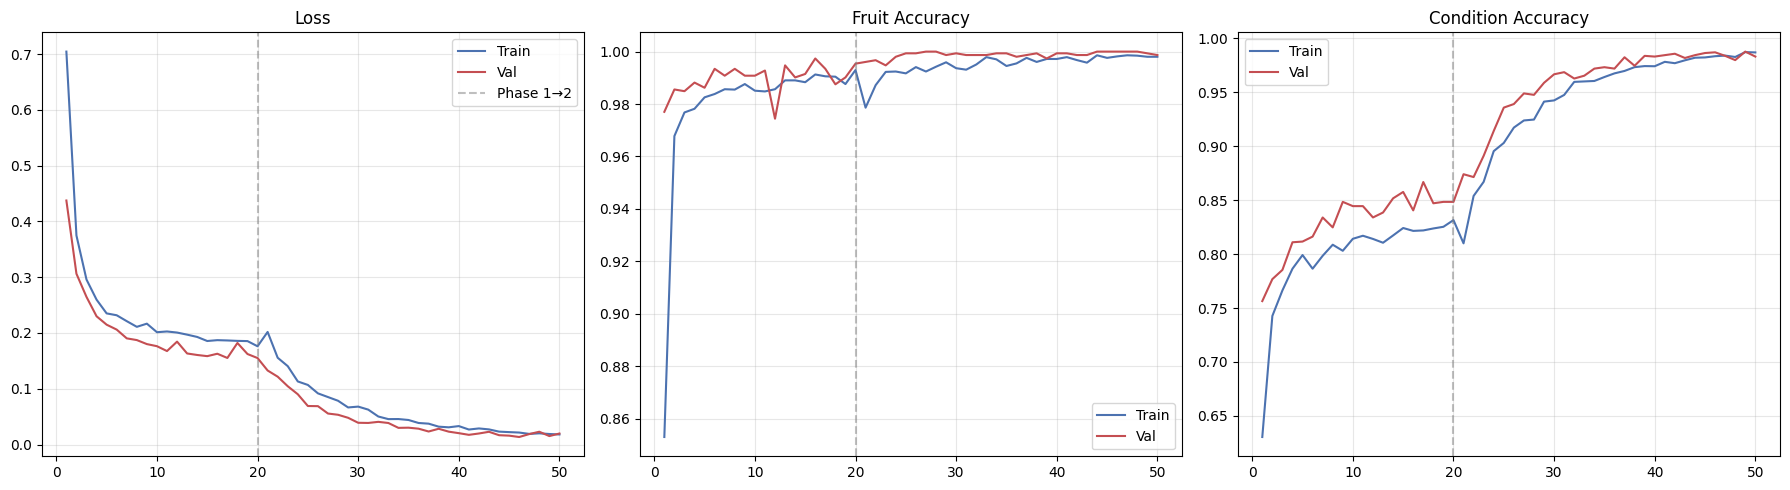

In [28]:
def plot_multihead_curves(h1, h2):
    """Plot training curves for both phases."""
    # Combine histories
    tl = h1['train_loss'] + h2['train_loss']
    vl = h1['val_loss']   + h2['val_loss']
    fa = h1['fruit_acc']  + h2['fruit_acc']
    ca = h1['cond_acc']   + h2['cond_acc']
    vfa = h1['val_fruit_acc'] + h2['val_fruit_acc']
    vca = h1['val_cond_acc']  + h2['val_cond_acc']
    epochs = range(1, len(tl)+1)
    boundary = len(h1['train_loss'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(epochs, tl, 'b-', label='Train')
    axes[0].plot(epochs, vl, 'r-', label='Val')
    axes[0].axvline(boundary, color='gray', ls='--', alpha=0.5, label='Phase 1→2')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Fruit accuracy
    axes[1].plot(epochs, fa, 'b-', label='Train')
    axes[1].plot(epochs, vfa, 'r-', label='Val')
    axes[1].axvline(boundary, color='gray', ls='--', alpha=0.5)
    axes[1].set_title('Fruit Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

    # Condition accuracy
    axes[2].plot(epochs, ca, 'b-', label='Train')
    axes[2].plot(epochs, vca, 'r-', label='Val')
    axes[2].axvline(boundary, color='gray', ls='--', alpha=0.5)
    axes[2].set_title('Condition Accuracy'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

plot_multihead_curves(history_p1, history_p2)

# Section 19 — Test Set Evaluation

Test:   0%|          | 0/48 [00:00<?, ?it/s]


TEST RESULTS
  Fruit accuracy:     0.9993 (99.9%)
  Condition accuracy: 0.9836 (98.4%)
  Combined accuracy:  0.9829 (98.3%)

--- Fruit Classification ---
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       306
      Banana       1.00      1.00      1.00       307
       Grape       1.00      1.00      1.00       301
       Mango       1.00      1.00      1.00       301
      Orange       1.00      1.00      1.00       309

    accuracy                           1.00      1524
   macro avg       1.00      1.00      1.00      1524
weighted avg       1.00      1.00      1.00      1524

--- Condition Classification ---
                precision    recall  f1-score   support

Formalin-mixed       0.99      0.98      0.98       476
         Fresh       0.98      0.98      0.98       572
        Rotten       0.99      0.99      0.99       476

      accuracy                           0.98      1524
     macro avg       0.98      0.98      

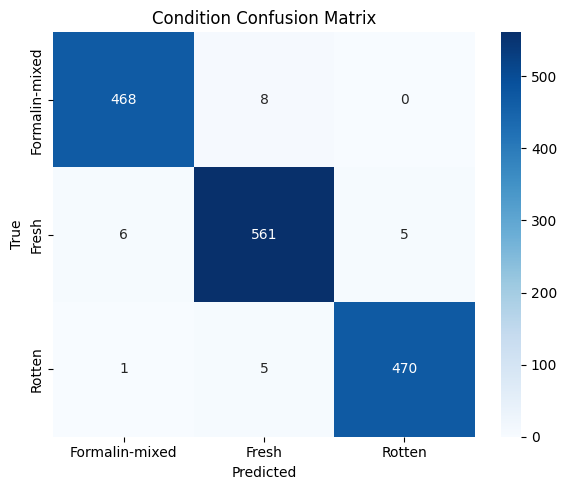

In [29]:
def evaluate_multihead(model, test_loader, class_names):
    model.eval()
    all_fruit_true, all_fruit_pred = [], []
    all_cond_true,  all_cond_pred  = [], []
    all_combo_true, all_combo_pred = [], []

    with torch.no_grad():
        for imgs, combo, fruits, conds in tqdm(test_loader, desc="Test"):
            imgs = imgs.to(DEVICE)
            f_logits, c_logits, _, _ = model(imgs)
            fp = f_logits.argmax(1).cpu().numpy()
            cp = c_logits.argmax(1).cpu().numpy()

            all_fruit_true.extend(fruits.numpy())
            all_fruit_pred.extend(fp)
            all_cond_true.extend(conds.numpy())
            all_cond_pred.extend(cp)
            all_combo_true.extend(combo.numpy())
            # Reconstruct combo prediction from fruit + condition
            for fi, ci in zip(fp, cp):
                combo_name = f"{FRUIT_NAMES[fi]}-{CONDITION_NAMES[ci]}"
                if combo_name in full_dataset.class_to_idx:
                    all_combo_pred.append(full_dataset.class_to_idx[combo_name])
                else:
                    all_combo_pred.append(-1)

    ft, fp = np.array(all_fruit_true), np.array(all_fruit_pred)
    ct, cp = np.array(all_cond_true),  np.array(all_cond_pred)
    cbt, cbp = np.array(all_combo_true), np.array(all_combo_pred)

    fruit_acc = np.mean(ft == fp)
    cond_acc  = np.mean(ct == cp)
    combo_acc = np.mean(cbt == cbp)

    print(f"\n{'='*55}")
    print(f"TEST RESULTS")
    print(f"{'='*55}")
    print(f"  Fruit accuracy:     {fruit_acc:.4f} ({fruit_acc*100:.1f}%)")
    print(f"  Condition accuracy: {cond_acc:.4f} ({cond_acc*100:.1f}%)")
    print(f"  Combined accuracy:  {combo_acc:.4f} ({combo_acc*100:.1f}%)")

    print(f"\n--- Fruit Classification ---")
    print(classification_report(ft, fp, target_names=FRUIT_NAMES))

    print(f"--- Condition Classification ---")
    print(classification_report(ct, cp, target_names=CONDITION_NAMES))

    # Condition confusion matrix
    cm = confusion_matrix(ct, cp)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CONDITION_NAMES, yticklabels=CONDITION_NAMES)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title('Condition Confusion Matrix')
    plt.tight_layout(); plt.show()

    return fruit_acc, cond_acc, combo_acc, ft, fp, ct, cp

fruit_acc, cond_acc, combo_acc, ft, fp, ct, cp = evaluate_multihead(
    model, test_loader, full_dataset.classes)

# Section 20 — OOD Detection (Mahalanobis Distance)
Extract 1280-dim features from all training images, compute per-class centroids and shared precision matrix, and calibrate the threshold.

In [30]:
def extract_features(model, dataset, indices, transform, batch_size=64):
    """Extract 1280-dim feature vectors from backbone."""
    subset = TransformedSubset(dataset, indices, transform)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=2)

    all_features = []
    all_combo    = []
    model.eval()
    with torch.no_grad():
        for imgs, combo, fruits, conds in tqdm(loader, desc="Extracting features"):
            _, _, _, feats = model(imgs.to(DEVICE))
            all_features.append(feats.cpu().numpy())
            all_combo.extend(combo.numpy())
    return np.vstack(all_features), np.array(all_combo)

# Extract training features
train_features, train_combo_labels = extract_features(
    model, full_dataset, train_idx, val_transform)  # val_transform = no aug

print(f"Feature matrix: {train_features.shape}")

# Compute per-class centroids
centroids = {}
for cls_idx, cls_name in enumerate(full_dataset.classes):
    mask = train_combo_labels == cls_idx
    if mask.sum() > 0:
        centroids[cls_name] = train_features[mask].mean(axis=0)

# Compute shared covariance across all classes (more stable than per-class)
all_diffs = []
for cls_idx, cls_name in enumerate(full_dataset.classes):
    mask = train_combo_labels == cls_idx
    if mask.sum() > 0:
        diffs = train_features[mask] - centroids[cls_name]
        all_diffs.append(diffs)

all_diffs = np.vstack(all_diffs)
cov_matrix = np.cov(all_diffs, rowvar=False)

# Regularise and invert
reg = 1e-4 * np.eye(cov_matrix.shape[0])
precision_matrix = np.linalg.inv(cov_matrix + reg)

print(f"Centroids: {len(centroids)} classes")
print(f"Precision matrix: {precision_matrix.shape}")

# ── Calibrate threshold ──────────────────────────────────────────────
# Compute Mahalanobis distance for all training samples
def mahalanobis_min(features, centroids, precision):
    """Compute min Mahalanobis distance to nearest centroid."""
    dists = np.full(len(features), np.inf)
    for cls_name, centroid in centroids.items():
        diff = features - centroid
        left = diff @ precision
        d = np.sqrt(np.sum(left * diff, axis=1))
        dists = np.minimum(dists, d)
    return dists

train_dists = mahalanobis_min(train_features, centroids, precision_matrix)

# Set threshold at 99th percentile of training distances
threshold = float(np.percentile(train_dists, 99))
print(f"\nOOD Threshold (99th pct of training): {threshold:.2f}")
print(f"  Training distance stats: mean={train_dists.mean():.2f}, "
      f"std={train_dists.std():.2f}, max={train_dists.max():.2f}")

# ── Save OOD config ──────────────────────────────────────────────────
ood_config = {
    'algorithm': 'Mahalanobis Distance',
    'threshold': threshold,
    'centroids': {k: v.tolist() for k, v in centroids.items()},
    'precision_matrix': precision_matrix.tolist(),
    'normalization': {
        'mean': [0.485, 0.456, 0.406],
        'std':  [0.229, 0.224, 0.225],
    },
    'input_size': IMG_SIZE,
}

ood_path = os.path.join(EXPORT_DIR, 'ood_config.json')
with open(ood_path, 'w') as f:
    json.dump(ood_config, f)
size_kb = os.path.getsize(ood_path) / 1024
print(f"\n✓ OOD config saved: {ood_path} ({size_kb:.0f} KB)")

Extracting features:   0%|          | 0/112 [00:00<?, ?it/s]

Feature matrix: (7107, 1280)
Centroids: 15 classes
Precision matrix: (1280, 1280)

OOD Threshold (99th pct of training): 43.93
  Training distance stats: mean=35.17, std=3.47, max=56.08

✓ OOD config saved: /kaggle/working/mobile_deploy/ood_config.json (32460 KB)


# Section 21 — Grad-CAM Explainability Visualisation

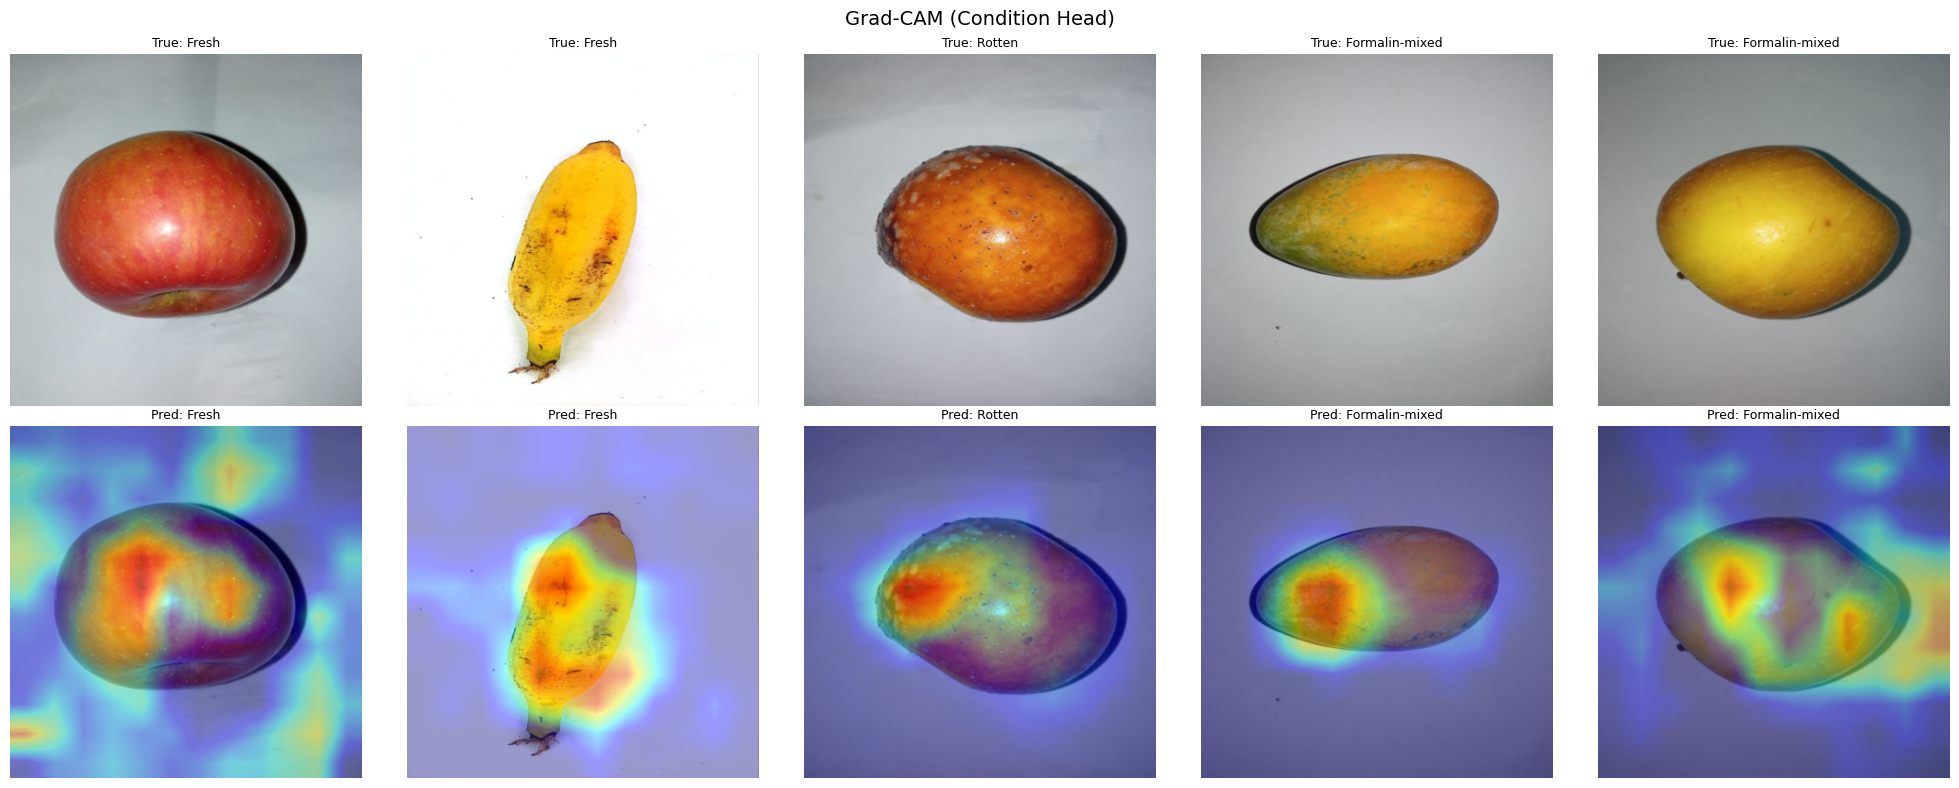

In [31]:
class GradCAM:
    """Grad-CAM for MultiHeadMobileNetV2 backbone."""
    def __init__(self, model):
        self.model = model
        self.target_layer = model.features[-1]
        self.gradients  = None
        self.activations = None
        self._fh = self.target_layer.register_forward_hook(self._save_act)
        self._bh = self.target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, inp, out):
        self.activations = out.detach()

    def _save_grad(self, m, gi, go):
        self.gradients = go[0].detach()

    def generate(self, input_tensor, head='fruit', target_class=None):
        self.model.eval()
        f_logits, c_logits, _, _ = self.model(input_tensor)
        logits = f_logits if head == 'fruit' else c_logits
        if target_class is None:
            target_class = logits.argmax(dim=1).item()
        self.model.zero_grad()
        logits[0, target_class].backward()
        w   = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((w * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=input_tensor.shape[2:],
                            mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, target_class

    def cleanup(self):
        self._fh.remove()
        self._bh.remove()


def show_gradcam(model, dataset, n=4):
    gcam = GradCAM(model)
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    for col, idx in enumerate(indices):
        img_t, combo, fruit, cond = dataset[idx]
        inp = img_t.unsqueeze(0).to(DEVICE)
        cam, pred = gcam.generate(inp, head='condition')
        img_np = (img_t.permute(1,2,0).numpy() * std + mean).clip(0, 1)

        axes[0, col].imshow(img_np)
        axes[0, col].set_title(f"True: {CONDITION_NAMES[cond]}", fontsize=9)
        axes[0, col].axis('off')

        axes[1, col].imshow(img_np)
        axes[1, col].imshow(cam, cmap='jet', alpha=0.4)
        axes[1, col].set_title(f"Pred: {CONDITION_NAMES[pred]}", fontsize=9)
        axes[1, col].axis('off')

    gcam.cleanup()
    plt.suptitle("Grad-CAM (Condition Head)", fontsize=14)
    plt.tight_layout(); plt.show()

show_gradcam(model, test_data, n=5)

# Section 22 — Export for Mobile Deployment
Produces three output files for the Android APK:
1. `yolo_fruits.tflite` — already exported in Section 8
2. `fruit_classifier.tflite` — this section
3. `ood_config.json` — already saved in Section 20

In [39]:
tflite_path = os.path.join(EXPORT_DIR, "fruit_classifier.tflite")
try:
    import subprocess
    subprocess.run(["pip", "install", "onnx2tf", "tensorflow", "-q"],
                   capture_output=True)
    import onnx2tf
    onnx2tf.convert(
        input_onnx_file_path=onnx_path,
        output_folder_path=os.path.join(EXPORT_DIR, "tf_model"),
        non_verbose=True,
    )
    tf_model_dir = os.path.join(EXPORT_DIR, "tf_model")
    for f in glob.glob(os.path.join(tf_model_dir, "**/*.tflite"), recursive=True):
        shutil.copy2(f, tflite_path)
        break
    if os.path.exists(tflite_path):
        size_mb = os.path.getsize(tflite_path) / 1024 / 1024
        print(f"✓ TFLite exported: {tflite_path} ({size_mb:.1f} MB)")
    else:
        print("⚠️  TFLite file not found after conversion")
except (Exception, SystemExit) as e:
    print(f"⚠️  TFLite conversion failed: {e}")
    print("  The .pth and .onnx files can be converted offline.")

I0000 00:00:1783950260.249572    4511 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1783950260.249931    4511 single_machine.cc:376] Starting new session
I0000 00:00:1783950260.251437    4511 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14731 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
W0000 00:00:1783950260.863610    4511 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783950260.863653    4511 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1783950261.418827    4511 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1783950261.419035    4511 single_machine.cc:376] Starting new session
I0000 00:00:1783950261.420097    4511 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14731 MB memory:  -> device: 0

✓ TFLite exported: /kaggle/working/mobile_deploy/fruit_classifier.tflite (5.3 MB)


In [43]:
from IPython.display import FileLink, display
import shutil, os

zip_path = shutil.make_archive('/kaggle/working/neural_bites_deploy', 'zip', EXPORT_DIR)
print(f"✓ Zip created: {zip_path}\n")

files_to_download = [
    'yolo_fruits.tflite',
    'fruit_classifier.tflite',
    'ood_config.json',
    'class_mapping.json',
    'runtime_config.json',
]

print("Individual files:")
for fname in files_to_download:
    fpath = os.path.join(EXPORT_DIR, fname)
    if os.path.exists(fpath):
        display(FileLink(fpath))
    else:
        print(f"✗ {fname} not found")

print("\nZip (all files together):")
display(FileLink(zip_path))

✓ Zip created: /kaggle/working/neural_bites_deploy.zip

Individual files:


/kaggle/working/mobile_deploy/yolo_fruits.tflite

/kaggle/working/mobile_deploy/fruit_classifier.tflite

/kaggle/working/mobile_deploy/ood_config.json

/kaggle/working/mobile_deploy/class_mapping.json

/kaggle/working/mobile_deploy/runtime_config.json


Zip (all files together):


/kaggle/working/neural_bites_deploy.zip

# Section 23 — Pipeline Summary

In [33]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              NEURAL BITES — PIPELINE COMPLETE               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Output Files for Android APK:                               ║
║    1. yolo_fruits.tflite        — fruit detection             ║
║    2. fruit_classifier.tflite   — classification + attention  ║
║    3. ood_config.json           — OOD rejection config        ║
║    4. class_mapping.json        — label mappings              ║
║    5. runtime_config.json       — inference parameters        ║
║                                                              ║
║  Mobile Architecture (4 Layers):                             ║
║    Layer 0: Quality check (blur/brightness)     [Kotlin]     ║
║    Layer 1: YOLO detection                      [TFLite]     ║
║    Layer 2: Classifier (fruit+condition+attn)   [TFLite]     ║
║    Layer 3: OOD detection + confidence gate     [Kotlin]     ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")

print(f"Fruit accuracy:     {fruit_acc:.4f}")
print(f"Condition accuracy: {cond_acc:.4f}")
print(f"Combined accuracy:  {combo_acc:.4f}")
print(f"OOD threshold:      {ood_config['threshold']:.2f}")


╔══════════════════════════════════════════════════════════════╗
║              NEURAL BITES — PIPELINE COMPLETE               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Output Files for Android APK:                               ║
║    1. yolo_fruits.tflite        — fruit detection             ║
║    2. fruit_classifier.tflite   — classification + attention  ║
║    3. ood_config.json           — OOD rejection config        ║
║    4. class_mapping.json        — label mappings              ║
║    5. runtime_config.json       — inference parameters        ║
║                                                              ║
║  Mobile Architecture (4 Layers):                             ║
║    Layer 0: Quality check (blur/brightness)     [Kotlin]     ║
║    Layer 1: YOLO detection                      [TFLite]     ║
║    Layer 2: Classifier (fruit+condition+attn)   [TFLite]     ║
║    Layer 3: OOD de

In [38]:
from IPython.display import FileLink, display
import shutil, os

zip_path = shutil.make_archive('/kaggle/working/neural_bites_deploy', 'zip', EXPORT_DIR)
print(f"✓ Zip created: {zip_path}\n")

files_to_download = [
    'yolo_fruits.tflite',
    'fruit_classifier.tflite',
    'ood_config.json',
    'class_mapping.json',
    'runtime_config.json',
]

print("Individual files:")
for fname in files_to_download:
    fpath = os.path.join(EXPORT_DIR, fname)
    if os.path.exists(fpath):
        display(FileLink(fpath))
    else:
        print(f"✗ {fname} not found")

print("\nZip (all files together):")
display(FileLink(zip_path))

✓ Zip created: /kaggle/working/neural_bites_deploy.zip

Individual files:


/kaggle/working/mobile_deploy/yolo_fruits.tflite

/kaggle/working/mobile_deploy/fruit_classifier.tflite

/kaggle/working/mobile_deploy/ood_config.json

✗ class_mapping.json not found
✗ runtime_config.json not found

Zip (all files together):


/kaggle/working/neural_bites_deploy.zip